# Notebook 05: Neural Parameterized Expectations Model
## Section 1 — Model Definition

### The Expectations Equation
We model the conditional expectation:

$$\hat{Y}_t = f_\theta(S_t)$$

Where:
- $S_t$ = macro-financial state (normalized features)
- $Y_t$ = yield curve vector [y1, y2, y5, y10, y20, y30]
- $f_\theta$ = neural network with learned parameters $\theta$

### Architecture
```
Input (d features)
 → Dense (64) → ReLU
 → Dense (64) → ReLU  
 → Dense (6 maturities)
```

In [2]:
pip install torch

  Using cached torch-2.9.1-cp313-cp313-win_amd64.whl.metadata (30 kB)
Using cached torch-2.9.1-cp313-cp313-win_amd64.whl (110.9 MB)
Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

from Src.Training.train import run_training, prepare_data
from Src.Models.neural_pea import NeuralPEA

## Section 2 — Training Curves

In [4]:
# Train the Neural PEA model
trainer, X, Y, tgt_cols = run_training(epochs=100, lr=1e-3, verbose=True)

Training Neural PEA: 15 features → 6 maturities
Train: 93, Val: 24
Epoch  10 | Train: 3.380706 | Val: 9.032313
Epoch  20 | Train: 0.654765 | Val: 0.999642
Epoch  30 | Train: 0.180836 | Val: 0.778147
Early stopping at epoch 33


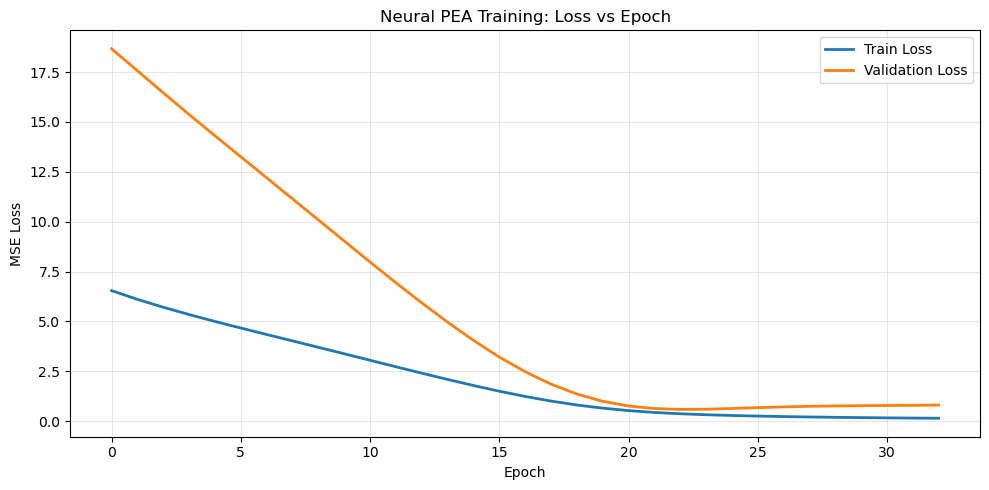

Final Train Loss: 0.149084
Final Val Loss: 0.807925


In [5]:
# Plot training curves
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(trainer.history['train_loss'], label='Train Loss', lw=2)
ax.plot(trainer.history['val_loss'], label='Validation Loss', lw=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Neural PEA Training: Loss vs Epoch')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final Train Loss: {trainer.history['train_loss'][-1]:.6f}")
print(f"Final Val Loss: {trainer.history['val_loss'][-1]:.6f}")

## Section 3 — OOS Performance vs Baselines

In [6]:
# Chronological split (same as training)
n_train = int(len(X) * 0.8)
X_train, X_test = X.iloc[:n_train], X.iloc[n_train:]
Y_train, Y_test = Y.iloc[:n_train], Y.iloc[n_train:]

# Neural PEA predictions
pea_preds = trainer.predict(X_test)
pea_mse = np.mean((pea_preds - Y_test.values) ** 2, axis=0)

# Baseline 1: Random Walk (predict last training value)
rw_pred = np.tile(Y_train.iloc[-1].values, (len(Y_test), 1))
rw_mse = np.mean((rw_pred - Y_test.values) ** 2, axis=0)

# Baseline 2: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, Y_train)
lr_preds = lr_model.predict(X_test)
lr_mse = np.mean((lr_preds - Y_test.values) ** 2, axis=0)

In [7]:
# Per-maturity MSE comparison table
results = pd.DataFrame({
    'Maturity': tgt_cols,
    'Random Walk': rw_mse,
    'Linear Reg': lr_mse,
    'Neural PEA': pea_mse
})
results['PEA vs RW (%)'] = ((rw_mse - pea_mse) / rw_mse * 100).round(1)
results['PEA vs LR (%)'] = ((lr_mse - pea_mse) / lr_mse * 100).round(1)
print("\n" + "="*70)
print("OUT-OF-SAMPLE MSE COMPARISON")
print("="*70)
print(results.to_string(index=False))
print("\nPositive % = Neural PEA improvement over baseline")


OUT-OF-SAMPLE MSE COMPARISON
Maturity  Random Walk  Linear Reg  Neural PEA  PEA vs RW (%)  PEA vs LR (%)
      y1     1.350942    0.297881    1.291851            4.4         -333.7
      y2     1.050454    0.364444    0.298099           71.6           18.2
      y5     0.712763    0.154536    0.660827            7.3         -327.6
     y10     0.458421    0.037376    0.084415           81.6         -125.9
     y20     0.400737    0.083409    1.100864         -174.7        -1219.8
     y30     0.301417    0.306820    0.114769           61.9           62.6

Positive % = Neural PEA improvement over baseline


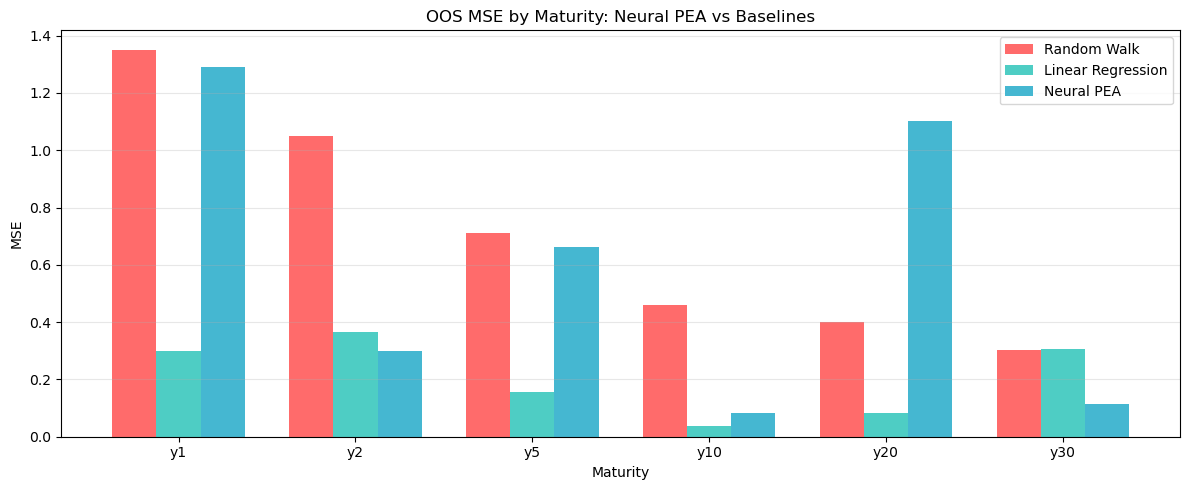

In [8]:
# Visualization
x = np.arange(len(tgt_cols))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, rw_mse, width, label='Random Walk', color='#ff6b6b')
ax.bar(x, lr_mse, width, label='Linear Regression', color='#4ecdc4')
ax.bar(x + width, pea_mse, width, label='Neural PEA', color='#45b7d1')

ax.set_xlabel('Maturity')
ax.set_ylabel('MSE')
ax.set_title('OOS MSE by Maturity: Neural PEA vs Baselines')
ax.set_xticks(x)
ax.set_xticklabels(tgt_cols)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [9]:
# Summary statistics
print("\n" + "="*50)
print("STEP 5 SUMMARY")
print("="*50)
print(f"Features: {X.shape[1]}")
print(f"Maturities: {len(tgt_cols)}")
print(f"Training samples: {n_train}")
print(f"Test samples: {len(X_test)}")
print(f"\nMean OOS MSE:")
print(f"  Random Walk: {rw_mse.mean():.6f}")
print(f"  Linear Reg:  {lr_mse.mean():.6f}")
print(f"  Neural PEA:  {pea_mse.mean():.6f}")
print(f"\nOverall PEA improvement vs RW: {((rw_mse.mean() - pea_mse.mean()) / rw_mse.mean() * 100):.1f}%")
print(f"Overall PEA improvement vs LR: {((lr_mse.mean() - pea_mse.mean()) / lr_mse.mean() * 100):.1f}%")


STEP 5 SUMMARY
Features: 15
Maturities: 6
Training samples: 93
Test samples: 24

Mean OOS MSE:
  Random Walk: 0.712456
  Linear Reg:  0.207411
  Neural PEA:  0.591804

Overall PEA improvement vs RW: 16.9%
Overall PEA improvement vs LR: -185.3%
